# 🚀 Thesis Experiment v2: SAC Asymmetric Portfolio (Capture Upside, Protect Downside)
**Setup:** 7-Day Rebalancing | SAC Algorithm | Multi-seed | XAI | **Asymmetric Reward**

## 🎯 Core Objective
> *"Naik kuat saat bull market, tetap aman saat bear market"*
> — Asymmetric Return Profile: High Upside Capture, Low Downside Capture

## 🆕 Improvements vs v1
| # | Improvement | Detail |
|---|-------------|--------|
| 1 | **Asymmetric Reward** | Sortino + Omega reward — hanya menghukum downside volatility |
| 2 | **Regime Features** | Tambah 3 fitur: vol_ratio, trend, drawdown level ke observasi |
| 3 | **Drawdown Penalty** | Penalti eksplisit saat drawdown besar di reward function |
| 4 | **Adaptive Gamma Center** | Gamma center bergerak sesuai kondisi pasar (bull/bear) |
| 5 | **Upside/Downside Capture** | Metrik baru untuk mengukur asymmetric profile |
| 6 | **Calmar-weighted reward** | Reward mempertimbangkan Calmar ratio (return/max_drawdown) |

## ⚙️ Global Settings

In [1]:
%pip install stable_baselines3[extra] shap --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ================================================================
# GLOBAL EXPERIMENT SETTINGS
# ================================================================
SEEDS         = [42, 123, 77]   # 3 seeds untuk kredibilitas statistik
TRAIN_STEPS   = 1000          # Steps untuk konvergensi SAC
GAMMA_CENTER  = 1.0
GAMMA_RANGE   = 1.0
SET_WINDOW    = 30
SET_REBALANCE = 7

# Asymmetric reward config
SORTINO_WINDOW  = 20    # rolling window untuk Sortino incremental
DD_PENALTY_ALPHA = 2.0  # bobot penalti drawdown
OMEGA_THRESHOLD  = 0.0  # threshold return untuk Omega ratio
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import warnings
import os
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import EvalCallback
from scipy.optimize import minimize
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print('Libraries loaded. SAC Asymmetric Mode active.')
print(f'Settings: Seeds={SEEDS}, Steps={TRAIN_STEPS}, Gamma={GAMMA_CENTER}')

Libraries loaded. SAC Asymmetric Mode active.
Settings: Seeds=[42, 123, 77], Steps=1000, Gamma=1.0


## Phase 1: Data Preparation

In [3]:
file_data = 'crypto_data_real.xlsx'

def load_and_split(filename, train_split=0.7):
    df = pd.read_excel(filename, sheet_name='Returns', index_col=0)
    df.index = pd.to_datetime(df.index)
    assets = list(df.columns)
    if 'USDT' in assets:
        assets.remove('USDT')
        print('USDT removed from assets.')
    assets.sort()
    df = df[assets]
    split_idx = int(len(df) * train_split)
    train_df = df.iloc[:split_idx]
    test_df  = df.iloc[split_idx:]
    return train_df, test_df, assets

ret_old, ret_test, assets = load_and_split(file_data)

print(f'Assets ({len(assets)}): {assets}')
print(f'Training : {ret_old.index[0].date()} – {ret_old.index[-1].date()} ({len(ret_old)} days)')
print(f'Test     : {ret_test.index[0].date()} – {ret_test.index[-1].date()} ({len(ret_test)} days)')

USDT removed from assets.
Assets (9): ['BCH', 'BNB', 'BTC', 'EOS', 'ETH', 'LTC', 'TRX', 'XLM', 'XRP']
Training : 2017-09-15 – 2019-03-02 (534 days)
Test     : 2019-03-03 – 2019-10-17 (229 days)


## Phase 2: Core Functions
### 2.1 Network & Markowitz Utilities

In [4]:
def apply_rmt_filter(returns_window):
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1/Q))**2
    eigenvalues[eigenvalues < lambda_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised


def get_centrality_weights(returns_window, gamma=1.0):
    T, N = returns_window.shape
    mu    = returns_window.mean().values
    sigma = returns_window.std().values
    corr_f = apply_rmt_filter(returns_window)
    cov_f  = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    fun  = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    bnds = tuple((0, 0.4) for _ in range(N))
    res  = minimize(fun, np.ones(N)/N, method='SLSQP', bounds=bnds, constraints=cons)
    return res.x if res.success else np.ones(N)/N


def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    N   = len(mu)
    fun = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    res = minimize(fun, np.ones(N)/N, method='SLSQP',
                   bounds=tuple((0, 0.4) for _ in range(N)), constraints=cons)
    return res.x if res.success else np.ones(N)/N


def get_network_metrics(returns_window):
    T, N = returns_window.shape
    corr_f  = apply_rmt_filter(returns_window)
# 1. Network Density (standard undirected: ignore diagonal)
upper_idx = np.triu_indices(N, k=1)
density   = np.sum(np.abs(corr_f[upper_idx]) > 0.1) / (N * (N - 1) / 2) if N > 1 else 0.0
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    mst_dist = sum(d['weight'] for _, _, d in mst.edges(data=True))
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return np.array([
        np.std(cent_vec)  * 10,
        np.mean(cent_vec) * 10,
        mst_dist          * 0.1,
        np.max(cent_vec),
        density
    ], dtype=np.float32)

print('Network & Markowitz utilities defined.')

Network & Markowitz utilities defined.


### 2.2 🆕 Regime Features — Deteksi Kondisi Pasar

In [5]:
def get_regime_features(returns_window):
    """
    [NEW] 3 fitur deteksi regime pasar untuk observasi agent:
    - vol_ratio  : recent_vol / long_vol — >1 berarti pasar sedang volatile
    - trend      : MA short - MA long — >0 berarti uptrend
    - drawdown   : current drawdown level dari peak — proxy bear market
    """
    recent_vol = returns_window.iloc[-5:].std().mean()
    long_vol   = returns_window.std().mean() + 1e-8
    vol_ratio  = recent_vol / long_vol       # >1 = volatile / bear signal

    ma_short = returns_window.iloc[-7:].mean().mean()
    ma_long  = returns_window.mean().mean()
    trend    = ma_short - ma_long            # >0 = uptrend / bull signal

    cumret = (1 + returns_window).cumprod()
    peak   = cumret.cummax()
    dd_now = ((cumret - peak) / peak).iloc[-1].mean()  # current drawdown

    return np.array([vol_ratio, trend * 100, dd_now * 10], dtype=np.float32)


def get_adaptive_gamma_center(vol_ratio, trend):
    """
    [NEW] Gamma center adaptif berdasarkan regime pasar.
    - Bear (vol tinggi + trend turun): gamma center lebih besar → lebih konservatif
    - Bull (vol rendah + trend naik) : gamma center lebih kecil → lebih agresif
    - Neutral                        : gamma center = GAMMA_CENTER (default)
    """
    if vol_ratio > 1.3 and trend < 0:      # Bear market
        return GAMMA_CENTER + 1.5
    elif vol_ratio < 0.8 and trend > 0:    # Bull market
        return GAMMA_CENTER - 0.5
    else:
        return GAMMA_CENTER                 # Neutral

print('Regime feature functions defined.')

Regime feature functions defined.


### 2.3 🆕 Asymmetric Reward Functions

In [6]:
def compute_sortino(returns_array, rf=0.0, min_periods=5):
    """
    Sortino ratio: hanya menghukum downside volatility (bukan total volatility).
    Ini mendorong agent untuk maximize return dengan menekan loss, 
    bukan sekadar minimize semua volatilitas.
    """
    if len(returns_array) < min_periods:
        return 0.0
    excess   = np.array(returns_array) - rf
    downside = np.sqrt(np.mean(np.minimum(excess, 0)**2) + 1e-8)
    return excess.mean() / downside


def compute_omega(returns_array, threshold=OMEGA_THRESHOLD):
    """
    Omega ratio: gains/losses diatas threshold.
    >1 = lebih banyak gain daripada loss.
    Agent didorong maximize ratio ini (asymmetric).
    """
    gains  = np.sum(np.maximum(np.array(returns_array) - threshold, 0))
    losses = np.sum(np.maximum(threshold - np.array(returns_array), 0))
    return np.log(gains / (losses + 1e-8) + 1e-8)


def compute_calmar_incremental(port_val, peak_val, returns_array, periods=252):
    """
    Calmar ratio incremental: ann_return / |max_drawdown|.
    Reward tinggi saat return bagus DAN drawdown kecil.
    """
    if len(returns_array) < 5:
        return 0.0
    ann_ret = (port_val ** (periods / len(returns_array))) - 1
    drawdown = (port_val - peak_val) / (peak_val + 1e-8)
    max_dd   = min(drawdown, -1e-8)   # pastikan negatif
    return ann_ret / abs(max_dd)


print('Asymmetric reward functions defined:')
print('  - compute_sortino   : penalize downside only')
print('  - compute_omega     : gains/losses ratio')
print('  - compute_calmar_incremental : return/max_drawdown')

Asymmetric reward functions defined:
  - compute_sortino   : penalize downside only
  - compute_omega     : gains/losses ratio
  - compute_calmar_incremental : return/max_drawdown


### 2.4 Performance Metrics (termasuk Upside/Downside Capture)

In [7]:
def calculate_metrics(returns_series):
    """Metrik performa portfolio lengkap termasuk Calmar Ratio."""
    total_ret = (1 + returns_series).prod() - 1
    ann_ret   = (1 + total_ret) ** (252 / len(returns_series)) - 1
    ann_vol   = returns_series.std() * np.sqrt(252)
    sharpe    = ann_ret / ann_vol if ann_vol > 0 else 0
    cumulative = (1 + returns_series).cumprod()
    peak       = cumulative.cummax()
    drawdown   = (cumulative - peak) / peak
    max_dd     = drawdown.min()
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0

    # Sortino ratio
    excess   = returns_series.values
    downside = np.sqrt(np.mean(np.minimum(excess, 0)**2) + 1e-8) * np.sqrt(252)
    sortino  = ann_ret / downside if downside > 0 else 0

    # Omega ratio
    gains  = np.sum(np.maximum(returns_series, 0))
    losses = np.sum(np.maximum(-returns_series, 0))
    omega  = gains / (losses + 1e-8)

    return {
        'Total Return'    : total_ret,
        'Ann. Return'     : ann_ret,
        'Ann. Volatility' : ann_vol,
        'Sharpe Ratio'    : sharpe,
        'Sortino Ratio'   : sortino,
        'Calmar Ratio'    : calmar,
        'Omega Ratio'     : omega,
        'Max Drawdown'    : max_dd,
    }


def updown_capture(strategy_ret, benchmark_ret):
    """
    [NEW] Upside/Downside Capture Ratio.
    - Upside Capture   > 1.0 : strategy naik LEBIH dari benchmark saat pasar naik ✅
    - Downside Capture < 1.0 : strategy turun LEBIH SEDIKIT dari benchmark saat turun ✅
    Target ideal: upside_capture > 1.0 AND downside_capture < 1.0
    """
    common = strategy_ret.index.intersection(benchmark_ret.index)
    s = strategy_ret.loc[common]
    b = benchmark_ret.loc[common]

    up_mask   = b > 0
    down_mask = b < 0

    up_capture   = (s[up_mask].mean()   / b[up_mask].mean()  ) if up_mask.sum() > 0 else np.nan
    down_capture = (s[down_mask].mean() / b[down_mask].mean()) if down_mask.sum() > 0 else np.nan

    return {
        'Upside Capture'  : up_capture,
        'Downside Capture': down_capture,
        'Capture Ratio'   : (up_capture / down_capture) if (down_capture and down_capture != 0) else np.nan,
    }

print('Performance metrics defined (Sortino, Omega, Calmar, Upside/Downside Capture).')

Performance metrics defined (Sortino, Omega, Calmar, Upside/Downside Capture).


### 2.5 Strategy Classes

In [8]:
class PortfolioStrategy:
    def __init__(self, name):
        self.name = name
        self.last_gamma = 1.0
    def compute_weights(self, returns_window): raise NotImplementedError()


class EquallyWeighted(PortfolioStrategy):
    def compute_weights(self, rw):
        return np.ones(rw.shape[1]) / rw.shape[1]


class ClassicalMarkowitz(PortfolioStrategy):
    def compute_weights(self, rw):
        cov = rw.cov().values
        inv_cov = np.linalg.pinv(cov)
        w = np.clip(inv_cov @ np.ones(cov.shape[0]), 0, 1)
        return w / np.sum(w)


class NetworkMarkowitz(PortfolioStrategy):
    def __init__(self, name, gamma=1.0):
        super().__init__(name)
        self.gamma = gamma
    def compute_weights(self, rw):
        return get_centrality_weights(rw, self.gamma)


class RLNetworkMarkowitz(PortfolioStrategy):
    """
    RL-based gamma controller menggunakan SAC.
    [NEW] Adaptive gamma center berdasarkan regime pasar.
    """
    def __init__(self, name, model_path, gamma_center=1.0, gamma_range=1.0, adaptive=True):
        super().__init__(name)
        self.model = SAC.load(model_path)
        self.gamma_center = gamma_center
        self.gamma_range  = gamma_range
        self.adaptive     = adaptive

    def compute_weights(self, rw):
        nw_feat     = get_network_metrics(rw)
        reg_feat    = get_regime_features(rw)           # [NEW] 3 regime features
        short_ret   = rw.iloc[-5:].mean().mean()
        long_ret    = rw.mean().mean()
        momentum    = short_ret - long_ret
        recent_vol  = rw.iloc[-5:].std().mean()
        mkt_feat    = np.array(
            [short_ret*100, momentum*100, recent_vol*100, 0.0],
            dtype=np.float32
        )
        # obs = nw(5) + mkt(4) + regime(3) = 12 features
        obs = np.nan_to_num(np.concatenate([nw_feat, mkt_feat, reg_feat]))
        action, _ = self.model.predict(obs, deterministic=True)

        # [NEW] Adaptive gamma center
        if self.adaptive:
            gc = get_adaptive_gamma_center(reg_feat[0], reg_feat[1])
        else:
            gc = self.gamma_center

        self.last_gamma = float(np.clip(action[0], -5.0, 5.0)) + gc
        return get_centrality_weights(rw, gamma=self.last_gamma)

print('Strategy classes defined.')

Strategy classes defined.


## Phase 3: Environment & Precompute

**[NEW]** Observation space diperluas dari 9 → **12 features**:
- `[0-4]` Network features (sama seperti v1)
- `[5-8]` Market features (sama seperti v1)  
- `[9]`  **vol_ratio** — deteksi volatilitas relative
- `[10]` **trend×100** — deteksi arah pasar
- `[11]` **drawdown×10** — current drawdown level

In [9]:
def precompute_env_data(returns_data, window_size=30):
    n_steps = len(returns_data) - window_size
    obs_cache, opt_cache, baseline_ret_cache = {}, {}, {}
    print(f'Precomputing {n_steps} window positions...')
    for i in range(window_size, len(returns_data)):
        win = returns_data.iloc[i - window_size : i]
        T, N = win.shape
        nw_feat   = get_network_metrics(win)
        reg_feat  = get_regime_features(win)              # [NEW]
        short_ret = win.iloc[-5:].mean().mean()
        long_ret  = win.mean().mean()
        mkt_feat  = np.array(
            [short_ret*100, (short_ret-long_ret)*100, win.iloc[-5:].std().mean()*100, 0.0],
            dtype=np.float32
        )
        obs_cache[i] = (nw_feat, mkt_feat, reg_feat)     # [NEW] simpan reg_feat

        mu    = win.mean().values
        sigma = win.std().values
        corr_f = apply_rmt_filter(win)
        cov_f  = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
        dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
        mst = nx.minimum_spanning_tree(nx.from_numpy_array(dist_mat))
        try:
            cent = nx.eigenvector_centrality(mst, max_iter=2000)
            cent_vec = np.array([cent[j] for j in range(N)])
        except:
            cent_vec = np.array(list(nx.degree_centrality(mst).values()))
        opt_cache[i] = (cov_f, cent_vec, mu)

        w_base = fast_centrality_weights(cov_f, cent_vec, mu, gamma=1.0)
        baseline_ret_cache[i] = np.dot(w_base, returns_data.iloc[i].values)

    print(f'Precomputation done! ({n_steps} positions cached)')
    return obs_cache, opt_cache, baseline_ret_cache

obs_cache, opt_cache, baseline_ret_cache = precompute_env_data(ret_old, window_size=SET_WINDOW)

Precomputing 504 window positions...
Precomputation done! (504 positions cached)


### 3.2 🆕 Asymmetric Portfolio Environment

**Reward modes baru:**
| Mode | Formula | Tujuan |
|------|---------|--------|
| `sortino_incremental` | Rolling Sortino (downside-only penalty) | Utama: asymmetric risk |
| `omega_reward` | log(gains/losses) | Maximize gain/loss ratio |
| `calmar_reward` | Sortino - DD_penalty×α | Sortino + eksplisit hukum drawdown |
| `excess_nw` | Excess return vs NW baseline | Baseline (v1) |

In [10]:
class AsymmetricPortfolioEnv(gym.Env):
    """
    [NEW] Asymmetric Portfolio Environment.
    
    Key differences vs v1:
    - Observation: 12 features (tambah 3 regime features)
    - Reward: asymmetric (Sortino / Omega / Calmar-penalized)
    - Adaptive gamma center berdasarkan regime
    - Explicit drawdown penalty
    """
    def __init__(self, returns_data, obs_cache, opt_cache,
                 baseline_ret_cache=None, window_size=30,
                 reward_mode='sortino_incremental',
                 gamma_center=1.0, gamma_range=1.0,
                 normalize_reward=True,
                 dd_penalty_alpha=DD_PENALTY_ALPHA,
                 adaptive_gamma=True):
        super().__init__()
        self.data               = returns_data
        self.obs_cache          = obs_cache
        self.opt_cache          = opt_cache
        self.baseline_ret_cache = baseline_ret_cache or {}
        self.window_size        = window_size
        self.reward_mode        = reward_mode
        self.gamma_center       = gamma_center
        self.gamma_range        = gamma_range
        self.normalize_reward   = normalize_reward
        self.dd_penalty_alpha   = dd_penalty_alpha
        self.adaptive_gamma     = adaptive_gamma
        self.current_step       = window_size
        self.port_val           = 1.0
        self.peak_val           = 1.0
        self._rew_mean  = 0.0
        self._rew_M2    = 0.0
        self._rew_count = 0
        self._ret_buffer = []

        # [NEW] obs space = 12 (5 network + 4 market + 3 regime)
        self.action_space      = spaces.Box(low=-5.0, high=5.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(12,), dtype=np.float32)

    def _get_obs(self):
        nw_feat, mkt_feat, reg_feat = self.obs_cache[self.current_step]
        mf = mkt_feat.copy()
        mf[3] = self.port_val - 1
        return np.nan_to_num(np.concatenate([nw_feat, mf, reg_feat]))

    def _adaptive_gamma_center(self):
        """[NEW] Shift gamma center sesuai regime pasar."""
        if not self.adaptive_gamma:
            return self.gamma_center
        _, _, reg_feat = self.obs_cache[self.current_step]
        return get_adaptive_gamma_center(reg_feat[0], reg_feat[1])

    def _normalize_reward(self, r):
        if not self.normalize_reward:
            return r
        self._rew_count += 1
        delta = r - self._rew_mean
        self._rew_mean += delta / self._rew_count
        delta2 = r - self._rew_mean
        self._rew_M2 += delta * delta2
        var = self._rew_M2 / self._rew_count if self._rew_count > 1 else 1.0
        std = max(np.sqrt(var), 1e-6)
        return np.clip(r / std, -10.0, 10.0)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        self.port_val     = 1.0
        self.peak_val     = 1.0
        self._ret_buffer  = []
        self._rew_mean  = 0.0
        self._rew_M2    = 0.0
        self._rew_count = 0
        return self._get_obs(), {}

    def step(self, action):
        gc    = self._adaptive_gamma_center()            # [NEW]
        gamma = float(np.clip(action[0], -5.0, 5.0)) + gc
        cov_f, cent_vec, mu = self.opt_cache[self.current_step]
        w        = fast_centrality_weights(cov_f, cent_vec, mu, gamma)
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)

        self.port_val *= (1 + port_ret)
        self.peak_val  = max(self.peak_val, self.port_val)
        drawdown = (self.port_val - self.peak_val) / self.peak_val
        nw_ret   = self.baseline_ret_cache.get(self.current_step, self.data.iloc[self.current_step].mean())

        self._ret_buffer.append(port_ret)
        if len(self._ret_buffer) > SORTINO_WINDOW:
            self._ret_buffer.pop(0)

        buf = np.array(self._ret_buffer)

        # ── Asymmetric Reward Computation ─────────────────────────────────
        if self.reward_mode == 'sortino_incremental':
            # [NEW] Sortino — only penalize downside
            raw = compute_sortino(buf) * 10

        elif self.reward_mode == 'omega_reward':
            # [NEW] Omega — log(gains/losses) asymmetric
            raw = compute_omega(buf) * 5

        elif self.reward_mode == 'calmar_reward':
            # [NEW] Sortino + explicit drawdown penalty
            sortino_r  = compute_sortino(buf) * 10
            dd_penalty = self.dd_penalty_alpha * abs(drawdown) * 100
            raw = sortino_r - dd_penalty

        elif self.reward_mode == 'excess_nw':
            raw = (port_ret - nw_ret) * 100

        else:
            raw = port_ret * 100

        reward = self._normalize_reward(raw)

        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        obs  = self._get_obs() if not done else np.zeros(self.observation_space.shape)

        return obs, float(reward), done, False, {}

print('AsymmetricPortfolioEnv defined.')
print('Observation space: 12 features (5 network + 4 market + 3 regime)')
print('Reward modes: sortino_incremental | omega_reward | calmar_reward | excess_nw')

AsymmetricPortfolioEnv defined.
Observation space: 12 features (5 network + 4 market + 3 regime)
Reward modes: sortino_incremental | omega_reward | calmar_reward | excess_nw


## Phase 4: Backtest Engine

In [11]:
def run_backtest_with_frequency(strategy, data, window=30, rebalance_freq=7):
    rets, dates, weights_history, gamma_history = [], [], [], []
    current_weights = None
    current_gamma   = 1.0
    print(f'Backtesting {strategy.name}...')
    for i in range(window, len(data)):
        if (i - window) % rebalance_freq == 0:
            window_df       = data.iloc[i-window:i]
            current_weights = strategy.compute_weights(window_df)
            current_gamma   = getattr(strategy, 'last_gamma', 1.0)
        if current_weights is not None:
            daily_ret = np.dot(current_weights, data.iloc[i].values)
            rets.append(daily_ret)
            dates.append(data.index[i])
            weights_history.append(current_weights)
            gamma_history.append(current_gamma)
    ret_series   = pd.Series(rets, index=dates, name=strategy.name)
    wts_df       = pd.DataFrame(weights_history, index=dates, columns=data.columns)
    gamma_series = pd.Series(gamma_history, index=dates, name=strategy.name)
    return ret_series, wts_df, gamma_series

print('Backtest engine defined.')

Backtest engine defined.


## Phase 5: SAC Training (Multi-Seed, Asymmetric Rewards)

**Reward modes yang dilatih:**
- `sortino_incremental` → SAC-Net (Sortino) — **recommended utama**
- `omega_reward`        → SAC-Net (Omega)
- `calmar_reward`       → SAC-Net (Calmar+DD)

In [12]:
sac_kwargs = {
    'policy'          : 'MlpPolicy',
    'learning_rate'   : 3e-4,
    'buffer_size'     : 50_000,
    'batch_size'      : 256,
    'ent_coef'        : 'auto',
    'train_freq'      : 1,
    'gradient_steps'  : 1,
    'learning_starts' : 1000,
    'tau'             : 0.005,
    'gamma'           : 0.99,
    'policy_kwargs'   : dict(net_arch=[256, 256]),  # sedikit lebih dalam
}

# [NEW] 3 reward modes asymmetric
reward_modes = {
    'sortino_incremental': 'SAC-Net (Sortino)',
    'omega_reward'       : 'SAC-Net (Omega)',
    'calmar_reward'      : 'SAC-Net (Calmar+DD)',
}

trained_models = {}

for mode, label in reward_modes.items():
    for seed in SEEDS:
        model_name = f'sac_asym_{mode}_seed{seed}'
        print(f'\nTraining [{label}] seed={seed}...')

        env = AsymmetricPortfolioEnv(
            ret_old, obs_cache, opt_cache, baseline_ret_cache,
            window_size=SET_WINDOW, reward_mode=mode,
            gamma_center=GAMMA_CENTER, gamma_range=GAMMA_RANGE,
            normalize_reward=True,
            dd_penalty_alpha=DD_PENALTY_ALPHA,
            adaptive_gamma=True
        )

        model = SAC(env=env, seed=seed, verbose=0, **sac_kwargs)
        model.learn(total_timesteps=TRAIN_STEPS, progress_bar=True)
        model.save(model_name)
        trained_models[(mode, seed)] = model_name
        print(f'  Saved: {model_name}.zip')

print('\n=== All SAC asymmetric models trained ===')


Training [SAC-Net (Sortino)] seed=42...


Output()

Output()

  Saved: sac_asym_sortino_incremental_seed42.zip

Training [SAC-Net (Sortino)] seed=123...


Output()

...

Output()

  Saved: sac_asym_calmar_reward_seed42.zip

Training [SAC-Net (Calmar+DD)] seed=123...


Output()

  Saved: sac_asym_calmar_reward_seed123.zip

Training [SAC-Net (Calmar+DD)] seed=77...


  Saved: sac_asym_calmar_reward_seed77.zip

=== All SAC asymmetric models trained ===


## Phase 6: In-Sample Backtest (Training Data)

In [13]:
COLORS = {
    'Equal Weight'           : 'dimgray',
    'Classical Markowitz'    : 'slategray',
    'NW (Gamma=1.0)'         : 'steelblue',
    'SAC-Net (Sortino)'      : 'darkorange',
    'SAC-Net (Omega)'        : 'green',
    'SAC-Net (Calmar+DD)'    : 'purple',
    'BTC (Buy & Hold)'       : 'black',
}

def run_multiseed_backtest(mode, label, data, seeds=SEEDS):
    seed_results = {}
    for seed in seeds:
        model_path = f'sac_asym_{mode}_seed{seed}'
        strat = RLNetworkMarkowitz(
            f'{label} [s{seed}]', model_path,
            gamma_center=GAMMA_CENTER, gamma_range=GAMMA_RANGE,
            adaptive=True
        )
        ret, _, gamma = run_backtest_with_frequency(
            strat, data, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
        )
        seed_results[seed] = (ret, gamma)
    return seed_results

def aggregate_seed_results(seed_results):
    all_rets = pd.DataFrame({s: r for s, (r, _) in seed_results.items()})
    return all_rets.mean(axis=1), all_rets.std(axis=1)

def bootstrap_cumret_bands(seed_results, n_boot=1000, ci=90, random_state=42):
    rng   = np.random.RandomState(random_state)
    seeds = list(seed_results.keys())
    cum_df = pd.DataFrame({s: (1 + seed_results[s][0]).cumprod() for s in seeds})
    cum_mean = cum_df.mean(axis=1)
    p_low, p_high = (100-ci)/2, 100-(100-ci)/2
    boot_means = []
    for _ in range(n_boot):
        sampled = rng.choice(seeds, size=len(seeds), replace=True)
        boot_means.append(cum_df[sampled].values.mean(axis=1))
    boot_arr = np.array(boot_means)
    return (cum_mean,
            pd.Series(np.percentile(boot_arr, p_low,  axis=0), index=cum_mean.index),
            pd.Series(np.percentile(boot_arr, p_high, axis=0), index=cum_mean.index))

print('Multi-seed backtest utilities defined.')

Multi-seed backtest utilities defined.


In [14]:
baseline_strategies = [
    EquallyWeighted('Equal Weight'),
    ClassicalMarkowitz('Classical Markowitz'),
    NetworkMarkowitz('NW (Gamma=1.0)', gamma=1.0),
]

results_train = {}
for s in baseline_strategies:
    ret, _, _ = run_backtest_with_frequency(s, ret_old, window=SET_WINDOW, rebalance_freq=SET_REBALANCE)
    results_train[s.name] = ret

if 'BTC' in ret_old.columns:
    results_train['BTC (Buy & Hold)'] = ret_old['BTC'].iloc[SET_WINDOW:]

sac_seed_results_train = {}
sac_gamma_train = {}
for mode, label in reward_modes.items():
    sr = run_multiseed_backtest(mode, label, ret_old)
    sac_seed_results_train[(mode, label)] = sr
    mean_ret, _ = aggregate_seed_results(sr)
    results_train[label] = mean_ret
    sac_gamma_train[label] = sr[SEEDS[0]][1]

print('In-sample backtest complete.')

Backtesting Equal Weight...
Backtesting Classical Markowitz...
Backtesting NW (Gamma=1.0)...
Backtesting SAC-Net (Sortino) [s42]...
Backtesting SAC-Net (Sortino) [s123]...
Backtesting SAC-Net (Sortino) [s77]...
Backtesting SAC-Net (Omega) [s42]...
Backtesting SAC-Net (Omega) [s123]...
Backtesting SAC-Net (Omega) [s77]...
Backtesting SAC-Net (Calmar+DD) [s42]...
Backtesting SAC-Net (Calmar+DD) [s123]...
Backtesting SAC-Net (Calmar+DD) [s77]...
In-sample backtest complete.


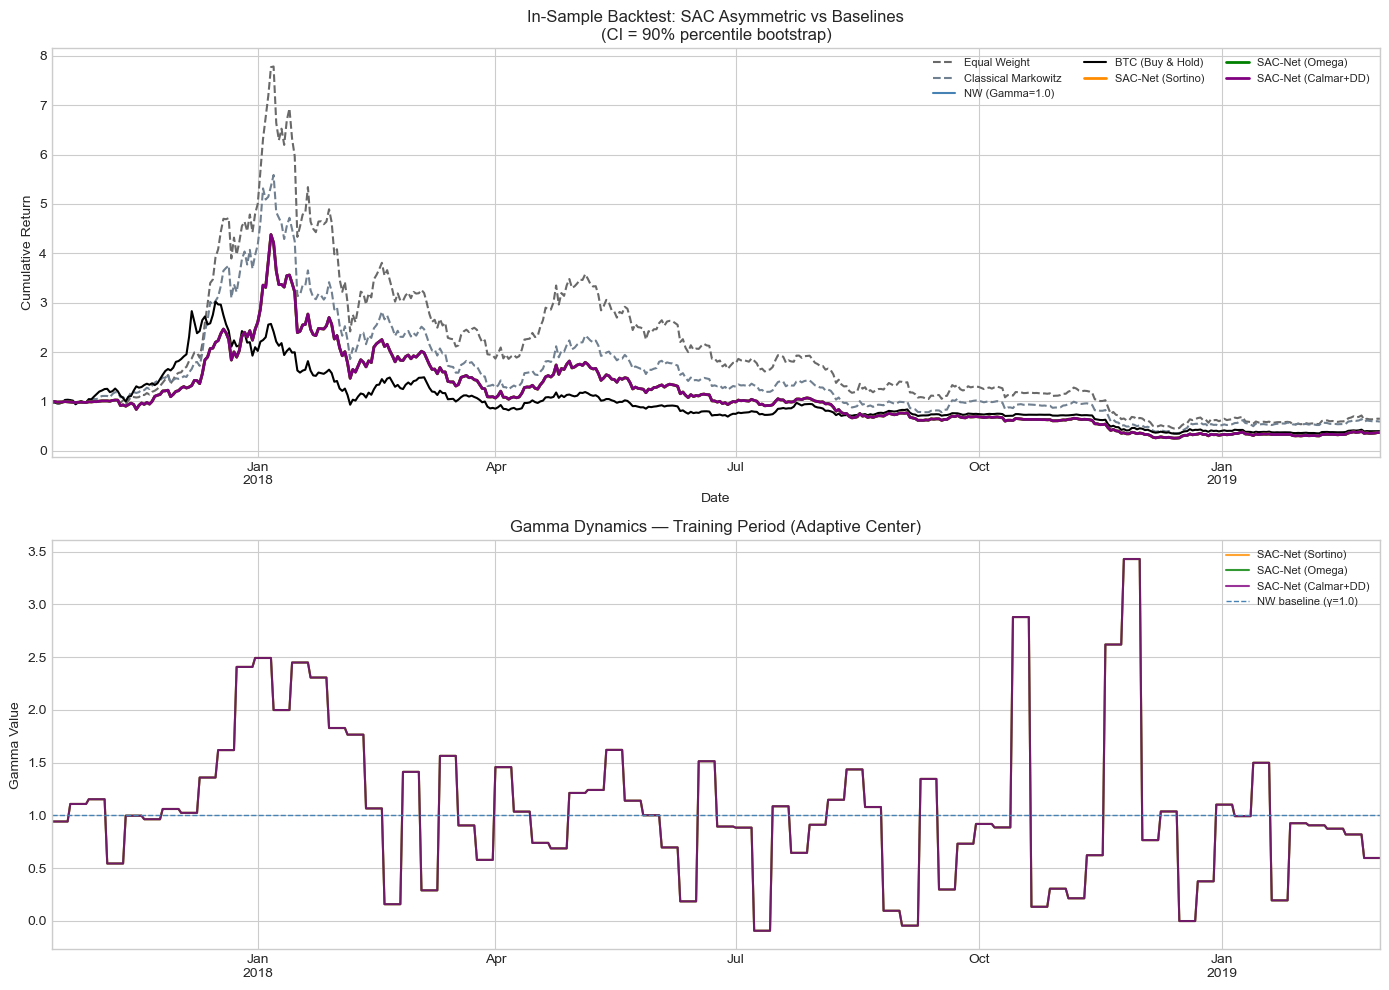

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Cumulative Returns
ax = axes[0]
for name, r in results_train.items():
    (1 + r).cumprod().plot(
        ax=ax, label=name, color=COLORS.get(name, 'gray'),
        linewidth=2.0 if 'SAC' in name else 1.5,
        linestyle='--' if name in ['Equal Weight', 'Classical Markowitz'] else '-'
    )
for mode, label in reward_modes.items():
    sr = sac_seed_results_train[(mode, label)]
    cum_mean, lower_band, upper_band = bootstrap_cumret_bands(sr)
    ax.fill_between(cum_mean.index, lower_band, upper_band,
                    alpha=0.12, color=COLORS.get(label, 'purple'))
ax.set_title('In-Sample Backtest: SAC Asymmetric vs Baselines\n(CI = 90% percentile bootstrap)')
ax.legend(fontsize=8, ncol=3)
ax.set_ylabel('Cumulative Return')

# Plot 2: Gamma Dynamics
ax2 = axes[1]
for label, g in sac_gamma_train.items():
    g.plot(ax=ax2, label=f'{label}', color=COLORS.get(label, 'gray'), alpha=0.8)
ax2.axhline(1.0, color='steelblue', linestyle='--', label='NW baseline (γ=1.0)', linewidth=1)
ax2.set_title('Gamma Dynamics — Training Period (Adaptive Center)')
ax2.set_ylabel('Gamma Value')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('backtest_results/train_cumret_asymmetric.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
os.makedirs('backtest_results', exist_ok=True)
stats_train = pd.DataFrame(
    {name: calculate_metrics(r) for name, r in results_train.items()}
).T
stats_train.index.name = 'Strategy'

print('=== In-Sample Performance Metrics ===')
print(stats_train.round(4).to_string())
stats_train.to_csv('backtest_results/train_metrics_asymmetric.csv')

=== In-Sample Performance Metrics ===
                     Total Return  Ann. Return  Ann. Volatility  Sharpe Ratio  Sortino Ratio  Calmar Ratio  Omega Ratio  Max Drawdown
Strategy                                                                                                                             
Equal Weight              -0.3509      -0.1944           0.8747       -0.2222        -0.3045       -0.2063       1.0361       -0.9421
Classical Markowitz       -0.4094      -0.2315           0.8426       -0.2747        -0.3837       -0.2472       1.0203       -0.9367
NW (Gamma=1.0)            -0.6291      -0.3910           0.8111       -0.4820        -0.6634       -0.4151       0.9642       -0.9419
BTC (Buy & Hold)          -0.6028      -0.3698           0.7135       -0.5183        -0.7152       -0.4176       0.9483       -0.8855
SAC-Net (Sortino)         -0.6321      -0.3935           0.8105       -0.4854        -0.6673       -0.4178       0.9632       -0.9417
SAC-Net (Omega)         

## Phase 7: 🆕 Upside/Downside Capture Analysis (Training)

Analisis apakah agent berhasil mencapai profil **asymmetric return**:
- Upside Capture > 1.0 ✅ (naik lebih dari benchmark saat bull)  
- Downside Capture < 1.0 ✅ (turun lebih sedikit saat bear)

=== Upside/Downside Capture Ratio (vs BTC (Buy & Hold)) ===
                     Upside Capture  Downside Capture  Capture Ratio
Strategy                                                            
Equal Weight                 1.1540            1.0506         1.0984
Classical Markowitz          1.0832            1.0031         1.0798
NW (Gamma=1.0)               0.9897            0.9794         1.0105
SAC-Net (Sortino)            0.9892            0.9800         1.0094
SAC-Net (Omega)              0.9892            0.9800         1.0094
SAC-Net (Calmar+DD)          0.9892            0.9800         1.0094


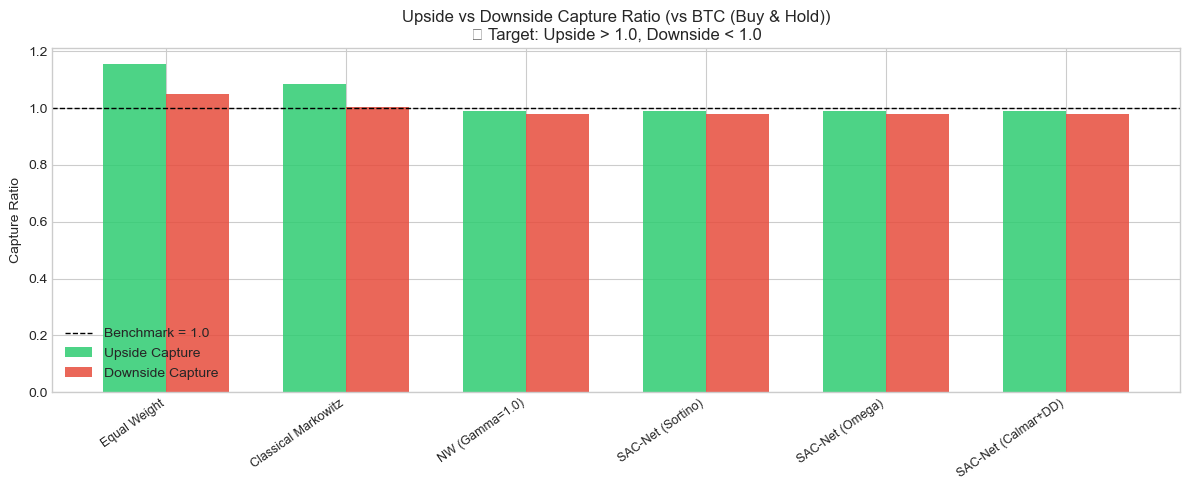

In [17]:
benchmark_name = 'BTC (Buy & Hold)'
if benchmark_name not in results_train:
    # fallback ke equal weight sebagai benchmark
    benchmark_name = 'Equal Weight'

benchmark_ret_train = results_train[benchmark_name]

capture_rows = []
for name, r in results_train.items():
    if name == benchmark_name:
        continue
    cap = updown_capture(r, benchmark_ret_train)
    cap['Strategy'] = name
    capture_rows.append(cap)

capture_df_train = pd.DataFrame(capture_rows).set_index('Strategy')
print(f'=== Upside/Downside Capture Ratio (vs {benchmark_name}) ===')
print(capture_df_train.round(4).to_string())
capture_df_train.to_csv('backtest_results/capture_ratio_train.csv')

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(capture_df_train))
width = 0.35
bars1 = ax.bar(x - width/2, capture_df_train['Upside Capture'],   width, label='Upside Capture',   color='#2ecc71', alpha=0.85)
bars2 = ax.bar(x + width/2, capture_df_train['Downside Capture'], width, label='Downside Capture', color='#e74c3c', alpha=0.85)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1, label='Benchmark = 1.0')
ax.set_xticks(x)
ax.set_xticklabels(capture_df_train.index, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Capture Ratio')
ax.set_title(f'Upside vs Downside Capture Ratio (vs {benchmark_name})\n✅ Target: Upside > 1.0, Downside < 1.0')
ax.legend()
plt.tight_layout()
plt.savefig('backtest_results/capture_ratio_train.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 8: Out-of-Sample Backtest (Validation 30%)

**Evaluasi generalisasi model pada data yang tidak pernah dilihat saat training.**

⚠️ *Limitasi: Backtest tidak memasukkan transaction cost. Hasil aktual mungkin ~0.05–0.20% lebih rendah per rebalancing.*

In [18]:
results_test = {}
for s in baseline_strategies:
    s2 = s.__class__(s.name, **({'gamma': s.gamma} if isinstance(s, NetworkMarkowitz) else {}))
    ret, _, _ = run_backtest_with_frequency(s2, ret_test, window=SET_WINDOW, rebalance_freq=SET_REBALANCE)
    results_test[s.name] = ret

if 'BTC' in ret_test.columns:
    results_test['BTC (Buy & Hold)'] = ret_test['BTC'].iloc[SET_WINDOW:]

sac_seed_results_test = {}
sac_gamma_test = {}
for mode, label in reward_modes.items():
    sr = run_multiseed_backtest(mode, label, ret_test)
    sac_seed_results_test[(mode, label)] = sr
    mean_ret, _ = aggregate_seed_results(sr)
    results_test[label] = mean_ret
    sac_gamma_test[label] = sr[SEEDS[0]][1]

print('Out-of-sample backtest complete.')

Backtesting Equal Weight...
Backtesting Classical Markowitz...
Backtesting NW (Gamma=1.0)...
Backtesting SAC-Net (Sortino) [s42]...
Backtesting SAC-Net (Sortino) [s123]...
Backtesting SAC-Net (Sortino) [s77]...
Backtesting SAC-Net (Omega) [s42]...
Backtesting SAC-Net (Omega) [s123]...
Backtesting SAC-Net (Omega) [s77]...
Backtesting SAC-Net (Calmar+DD) [s42]...
Backtesting SAC-Net (Calmar+DD) [s123]...
Backtesting SAC-Net (Calmar+DD) [s77]...
Out-of-sample backtest complete.


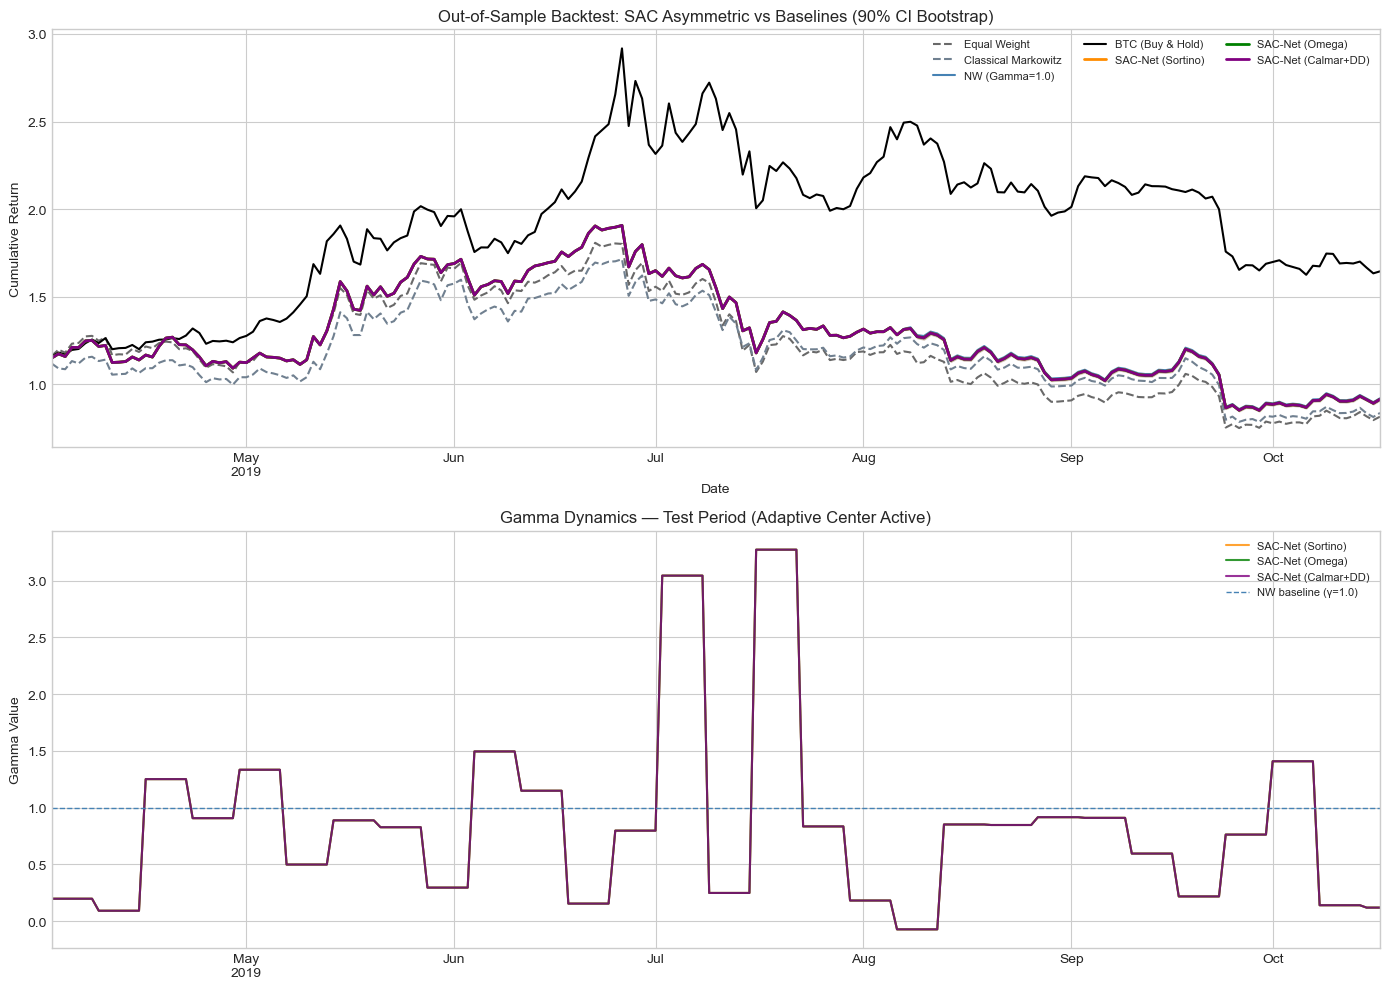

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax = axes[0]
for name, r in results_test.items():
    (1 + r).cumprod().plot(
        ax=ax, label=name, color=COLORS.get(name, 'gray'),
        linewidth=2.0 if 'SAC' in name else 1.5,
        linestyle='--' if name in ['Equal Weight', 'Classical Markowitz'] else '-'
    )
for mode, label in reward_modes.items():
    sr = sac_seed_results_test[(mode, label)]
    cum_mean, lower, upper = bootstrap_cumret_bands(sr)
    ax.fill_between(cum_mean.index, lower, upper, alpha=0.12, color=COLORS.get(label, 'purple'))
ax.set_title('Out-of-Sample Backtest: SAC Asymmetric vs Baselines (90% CI Bootstrap)')
ax.legend(fontsize=8, ncol=3)
ax.set_ylabel('Cumulative Return')

ax2 = axes[1]
for label, g in sac_gamma_test.items():
    g.plot(ax=ax2, label=label, color=COLORS.get(label, 'gray'), alpha=0.8)
ax2.axhline(1.0, color='steelblue', linestyle='--', linewidth=1, label='NW baseline (γ=1.0)')
ax2.set_title('Gamma Dynamics — Test Period (Adaptive Center Active)')
ax2.set_ylabel('Gamma Value')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('backtest_results/test_cumret_asymmetric.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
stats_test = pd.DataFrame(
    {name: calculate_metrics(r) for name, r in results_test.items()}
).T
stats_test.index.name = 'Strategy'
stats_test.to_csv('backtest_results/test_metrics_asymmetric.csv')
print('=== Out-of-Sample Performance Metrics ===')
print(stats_test.round(4).to_string())

=== Out-of-Sample Performance Metrics ===
                     Total Return  Ann. Return  Ann. Volatility  Sharpe Ratio  Sortino Ratio  Calmar Ratio  Omega Ratio  Max Drawdown
Strategy                                                                                                                             
Equal Weight              -0.1844      -0.2275           0.6606       -0.3443        -0.4635       -0.3890       0.9899       -0.5848
Classical Markowitz       -0.1628      -0.2015           0.6321       -0.3188        -0.4262       -0.3722       0.9939       -0.5414
NW (Gamma=1.0)            -0.0791      -0.0991           0.6227       -0.1592        -0.2189       -0.1802       1.0272       -0.5502
BTC (Buy & Hold)           0.6451       0.8783           0.6550        1.3410         2.0113        1.9834       1.2674       -0.4428
SAC-Net (Sortino)         -0.0849      -0.1062           0.6227       -0.1706        -0.2346       -0.1920       1.0248       -0.5533
SAC-Net (Omega)     

## Phase 9: 🆕 Upside/Downside Capture (Out-of-Sample)

=== OOS Upside/Downside Capture (vs BTC (Buy & Hold)) ===
                     Upside Capture  Downside Capture  Capture Ratio
Strategy                                                            
Equal Weight                 0.7151            0.9179         0.7790
Classical Markowitz          0.7025            0.8971         0.7831
NW (Gamma=1.0)               0.6888            0.8441         0.8160
SAC-Net (Sortino)            0.6877            0.8453         0.8136
SAC-Net (Omega)              0.6877            0.8453         0.8136
SAC-Net (Calmar+DD)          0.6877            0.8453         0.8136


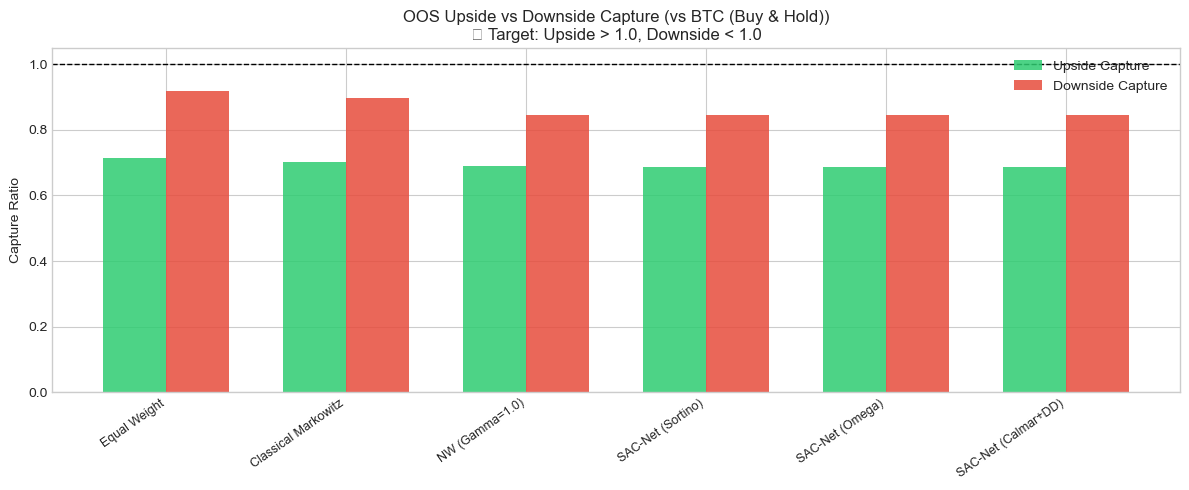

In [21]:
if benchmark_name in results_test:
    benchmark_ret_test = results_test[benchmark_name]
    cap_rows_test = []
    for name, r in results_test.items():
        if name == benchmark_name:
            continue
        cap = updown_capture(r, benchmark_ret_test)
        cap['Strategy'] = name
        cap_rows_test.append(cap)
    capture_df_test = pd.DataFrame(cap_rows_test).set_index('Strategy')
    capture_df_test.to_csv('backtest_results/capture_ratio_test.csv')

    print(f'=== OOS Upside/Downside Capture (vs {benchmark_name}) ===')
    print(capture_df_test.round(4).to_string())

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(capture_df_test))
    ax.bar(x - width/2, capture_df_test['Upside Capture'],   width, label='Upside Capture',   color='#2ecc71', alpha=0.85)
    ax.bar(x + width/2, capture_df_test['Downside Capture'], width, label='Downside Capture', color='#e74c3c', alpha=0.85)
    ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(capture_df_test.index, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Capture Ratio')
    ax.set_title(f'OOS Upside vs Downside Capture (vs {benchmark_name})\n✅ Target: Upside > 1.0, Downside < 1.0')
    ax.legend()
    plt.tight_layout()
    plt.savefig('backtest_results/capture_ratio_test.png', dpi=150, bbox_inches='tight')
    plt.show()

## Phase 10: Statistical Significance Tests

In [22]:
def diebold_mariano_test(returns1, returns2, h=1):
    d    = np.array(returns1) - np.array(returns2)
    T    = float(len(d))
    d_bar = np.mean(d)
    def autocovariance(xi, k):
        N, xs = len(xi), xi - np.mean(xi)
        return np.sum(xs**2)/N if k==0 else np.sum(xs[k:]*xs[:-k])/N
    var_d_bar = autocovariance(d, 0)
    if h > 1:
        for lag in range(1, h):
            var_d_bar += 2*(1-lag/h)*autocovariance(d, lag)
    var_d_bar /= T
    if var_d_bar <= 0:
        return 0.0, 1.0
    dm_stat = d_bar / np.sqrt(var_d_bar)
    p_value = 2*(1 - stats.norm.cdf(abs(dm_stat)))
    return dm_stat, p_value

# Run significance tests OOS
results_sig = []
target_strats = [s for s in results_test.keys() if 'SAC' in s or s in ['NW (Gamma=1.0)', 'Equal Weight']]
for i in range(len(target_strats)):
    for j in range(i+1, len(target_strats)):
        s1, s2 = target_strats[i], target_strats[j]
        r1, r2 = results_test[s1], results_test[s2]
        min_len = min(len(r1), len(r2))
        r1, r2  = r1.iloc[:min_len], r2.iloc[:min_len]
        t_stat, t_p   = stats.ttest_rel(r1, r2)
        dm_stat, dm_p = diebold_mariano_test(r1, r2, h=1)
        results_sig.append({
            'Comparison': f'{s1} vs {s2}',
            'DM-Stat': round(dm_stat, 4),
            'DM p-value': round(dm_p, 4),
            'T-Stat': round(t_stat, 4),
            'T p-value': round(t_p, 4),
            'Significant': 'Yes*' if dm_p < 0.05 else 'No'
        })

df_sig = pd.DataFrame(results_sig)
print('=== Statistical Significance (OOS) ===')
print(df_sig.to_string(index=False))
df_sig.to_csv('backtest_results/significance_test.csv', index=False)

=== Statistical Significance (OOS) ===
                              Comparison  DM-Stat  DM p-value  T-Stat  T p-value Significant
          Equal Weight vs NW (Gamma=1.0)  -0.8463      0.3974 -0.8442     0.3996          No
       Equal Weight vs SAC-Net (Sortino)  -0.7988      0.4244 -0.7968     0.4265          No
         Equal Weight vs SAC-Net (Omega)  -0.7988      0.4244 -0.7968     0.4265          No
     Equal Weight vs SAC-Net (Calmar+DD)  -0.7988      0.4244 -0.7968     0.4265          No
     NW (Gamma=1.0) vs SAC-Net (Sortino)   1.3060      0.1916  1.3027     0.1942          No
       NW (Gamma=1.0) vs SAC-Net (Omega)   1.3060      0.1916  1.3027     0.1942          No
   NW (Gamma=1.0) vs SAC-Net (Calmar+DD)   1.3060      0.1916  1.3027     0.1942          No
    SAC-Net (Sortino) vs SAC-Net (Omega)   0.0000      1.0000     NaN        NaN          No
SAC-Net (Sortino) vs SAC-Net (Calmar+DD)   0.0000      1.0000     NaN        NaN          No
  SAC-Net (Omega) vs SAC-Net (C

## Phase 11: Explainability AI (XAI)

**[NEW]** Feature names diperluas ke 12 (tambah 3 regime features):
- `[9]`  vol_ratio — deteksi volatilitas relatif
- `[10]` trend×100 — sinyal arah pasar
- `[11]` drawdown×10 — level drawdown saat ini

In [23]:
import shap

FEATURE_NAMES = [
    'Centrality Std×10',     # nw[0]
    'Centrality Mean×10',    # nw[1]
    'MST Distance×0.1',      # nw[2]
    'Max Centrality',        # nw[3]
    'Corr Density',          # nw[4]
    'Short Return×100',      # mkt[0]
    'Momentum×100',          # mkt[1]
    'Recent Vol×100',        # mkt[2]
    'Portfolio PnL',         # mkt[3]
    'Vol Ratio',             # reg[0] [NEW]
    'Trend×100',             # reg[1] [NEW]
    'Drawdown×10',           # reg[2] [NEW]
]

def collect_observations(data, obs_cache, window_size=30, max_obs=300):
    obs_list = []
    steps = sorted(obs_cache.keys())
    step_sample = steps[::max(1, len(steps)//max_obs)][:max_obs]
    for step in step_sample:
        nw_feat, mkt_feat, reg_feat = obs_cache[step]
        mf = mkt_feat.copy(); mf[3] = 0.0
        obs = np.nan_to_num(np.concatenate([nw_feat, mf, reg_feat]))
        obs_list.append(obs)
    return np.array(obs_list, dtype=np.float32)

def get_gamma_predictions(model, observations, gamma_center=GAMMA_CENTER):
    gammas = []
    for obs in observations:
        action, _ = model.predict(np.nan_to_num(obs), deterministic=True)
        gammas.append(float(np.clip(action[0], -5.0, 5.0)) + gamma_center)
    return np.array(gammas)

print(f'XAI setup done. Feature count: {len(FEATURE_NAMES)}')
for i, fn in enumerate(FEATURE_NAMES):
    marker = ' [NEW]' if i >= 9 else ''
    print(f'  [{i:2d}] {fn}{marker}')

XAI setup done. Feature count: 12
  [ 0] Centrality Std×10
  [ 1] Centrality Mean×10
  [ 2] MST Distance×0.1
  [ 3] Max Centrality
  [ 4] Corr Density
  [ 5] Short Return×100
  [ 6] Momentum×100
  [ 7] Recent Vol×100
  [ 8] Portfolio PnL
  [ 9] Vol Ratio [NEW]
  [10] Trend×100 [NEW]
  [11] Drawdown×10 [NEW]


### 11.1 SHAP Global Feature Importance

Model loaded: sac_asym_sortino_incremental_seed42
Observations: (300, 12)
Computing SHAP values (~1-2 min)...


  0%|          | 0/100 [00:00<?, ?it/s]

SHAP done. Shape: (100, 12)


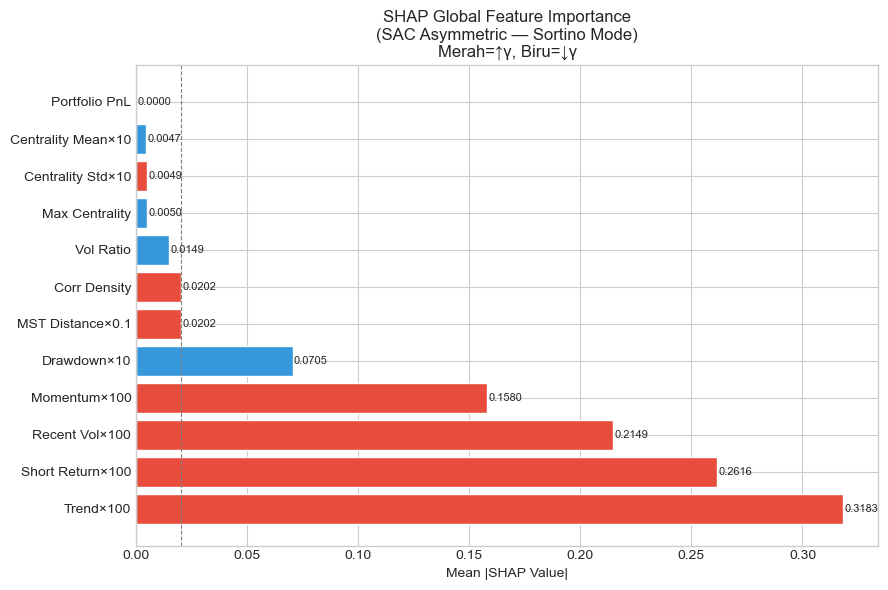

           Feature  Mean |SHAP|     Direction
         Trend×100      0.31829  ↑ Gamma naik
  Short Return×100      0.26161  ↑ Gamma naik
    Recent Vol×100      0.21488  ↑ Gamma naik
      Momentum×100      0.15796  ↑ Gamma naik
       Drawdown×10      0.07053 ↓ Gamma turun
  MST Distance×0.1      0.02017  ↑ Gamma naik
      Corr Density      0.02017  ↑ Gamma naik
         Vol Ratio      0.01486 ↓ Gamma turun
    Max Centrality      0.00505 ↓ Gamma turun
 Centrality Std×10      0.00492  ↑ Gamma naik
Centrality Mean×10      0.00467 ↓ Gamma turun
     Portfolio PnL      0.00000 ↓ Gamma turun


In [24]:
_mode_xai  = 'sortino_incremental'
_label_xai = reward_modes[_mode_xai]
_seed_xai  = SEEDS[0]
_model_path = f'sac_asym_{_mode_xai}_seed{_seed_xai}'

sac_model_xai = SAC.load(_model_path)
print(f'Model loaded: {_model_path}')

X_obs = collect_observations(ret_old, obs_cache, window_size=SET_WINDOW, max_obs=300)
print(f'Observations: {X_obs.shape}')

def predict_gamma(X):
    return np.array([
        float(np.clip(sac_model_xai.predict(np.nan_to_num(obs), deterministic=True)[0][0], -5.0, 5.0)) + GAMMA_CENTER
        for obs in X
    ])

background   = shap.kmeans(X_obs, 50)
print('Computing SHAP values (~1-2 min)...')
explainer    = shap.KernelExplainer(predict_gamma, background)
shap_values  = explainer.shap_values(X_obs[:100], nsamples=100)
print(f'SHAP done. Shape: {np.array(shap_values).shape}')

# Plot SHAP bar
fig, ax = plt.subplots(figsize=(9, 6))
mean_abs_shap = np.abs(shap_values).mean(axis=0)
sorted_idx    = np.argsort(mean_abs_shap)[::-1]
colors_bar    = ['#e74c3c' if shap_values.mean(axis=0)[i]>0 else '#3498db' for i in sorted_idx]
bars = ax.barh([FEATURE_NAMES[i] for i in sorted_idx], mean_abs_shap[sorted_idx],
               color=colors_bar, edgecolor='white')
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('SHAP Global Feature Importance\n(SAC Asymmetric — Sortino Mode)\nMerah=↑γ, Biru=↓γ')
ax.axvline(np.median(mean_abs_shap), color='gray', linestyle='--', linewidth=0.8)
for bar, val in zip(bars, mean_abs_shap[sorted_idx]):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('backtest_results/xai_shap_global_v2.png', dpi=150, bbox_inches='tight')
plt.show()

shap_df = pd.DataFrame({
    'Feature'   : FEATURE_NAMES,
    'Mean |SHAP|': mean_abs_shap,
    'Direction' : ['↑ Gamma naik' if v>0 else '↓ Gamma turun' for v in shap_values.mean(axis=0)]
}).sort_values('Mean |SHAP|', ascending=False)
print(shap_df.round(5).to_string(index=False))
shap_df.to_csv('backtest_results/xai_shap_importance_v2.csv')

### 11.2 Sensitivity Analysis

=== Sensitivity Analysis ===
           Feature  Δγ (+1 std)  Δγ (-1 std)  |Δγ| avg Is Regime?
         Trend×100     -0.27287      0.61487   0.44387      [NEW]
  Short Return×100      0.17595     -0.41204   0.29400           
      Momentum×100     -0.28351      0.13290   0.20820           
    Recent Vol×100     -0.01158     -0.22542   0.11850           
       Drawdown×10     -0.17396      0.00732   0.09064      [NEW]
         Vol Ratio      0.02286     -0.01748   0.02017      [NEW]
  MST Distance×0.1      0.02090     -0.00533   0.01312           
      Corr Density      0.00694     -0.01479   0.01087           
 Centrality Std×10      0.00157     -0.00157   0.00157           
Centrality Mean×10     -0.00138      0.00138   0.00138           
    Max Centrality     -0.00031      0.00031   0.00031           
     Portfolio PnL      0.00000      0.00000   0.00000           


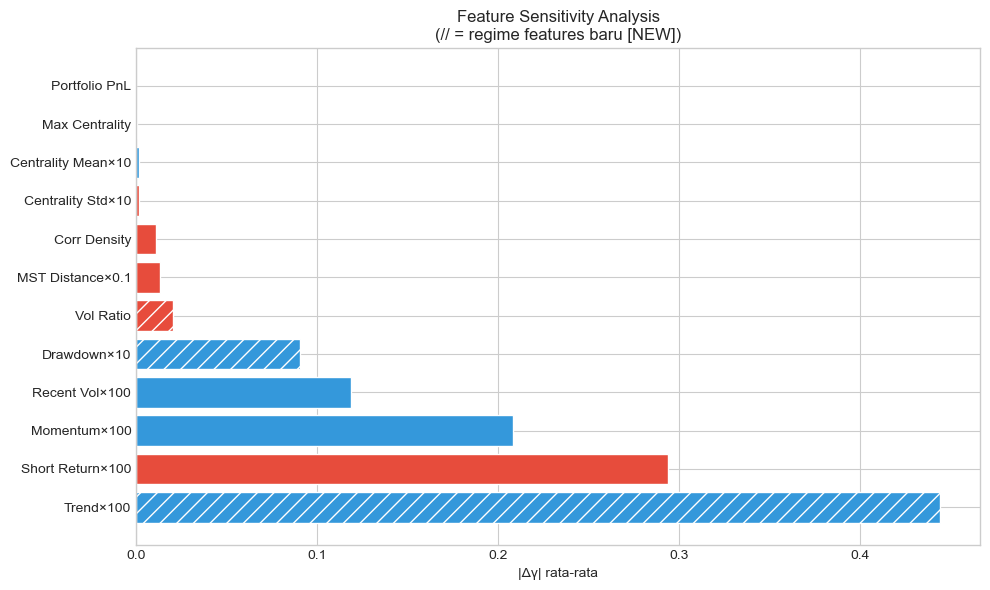

In [25]:
X_median = np.median(X_obs, axis=0)
X_std    = X_obs.std(axis=0)

sensitivity_results = []
for i, fname in enumerate(FEATURE_NAMES):
    gamma_base = predict_gamma(X_median.reshape(1,-1))[0]
    X_up = X_median.copy(); X_up[i] += X_std[i]
    X_dn = X_median.copy(); X_dn[i] -= X_std[i]
    delta_up = predict_gamma(X_up.reshape(1,-1))[0] - gamma_base
    delta_dn = predict_gamma(X_dn.reshape(1,-1))[0] - gamma_base
    sensitivity_results.append({
        'Feature'     : fname,
        'Δγ (+1 std)' : round(delta_up, 5),
        'Δγ (-1 std)' : round(delta_dn, 5),
        '|Δγ| avg'    : round((abs(delta_up)+abs(delta_dn))/2, 5),
        'Is Regime?'  : '[NEW]' if i >= 9 else '',
    })

sens_df = pd.DataFrame(sensitivity_results).sort_values('|Δγ| avg', ascending=False)
print('=== Sensitivity Analysis ===')
print(sens_df.to_string(index=False))
sens_df.to_csv('backtest_results/xai_sensitivity_v2.csv')

fig, ax = plt.subplots(figsize=(10, 6))
colors_s = ['#e74c3c' if d>0 else '#3498db' for d in sens_df['Δγ (+1 std)']]
bars = ax.barh(sens_df['Feature'], sens_df['|Δγ| avg'], color=colors_s, edgecolor='white')
for i, (bar, row) in enumerate(zip(bars, sens_df.itertuples())):
    if row._5 == '[NEW]':
        bar.set_hatch('//')
        bar.set_edgecolor('white')
ax.set_xlabel('|Δγ| rata-rata')
ax.set_title('Feature Sensitivity Analysis\n(// = regime features baru [NEW])')
plt.tight_layout()
plt.savefig('backtest_results/xai_sensitivity_v2.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.3 Regime Correlation Analysis

Pearson  Gamma~Vol : 0.0999
Pearson  Gamma~Mom : -0.2116
Spearman Gamma~Vol : -0.0014 (p=0.9846)
Spearman Gamma~Mom : -0.1784 (p=0.0130)
Gamma High Vol: 0.9447 ± 0.8793
Gamma Low  Vol: 0.7895 ± 0.6400
T-test p: 0.1628 


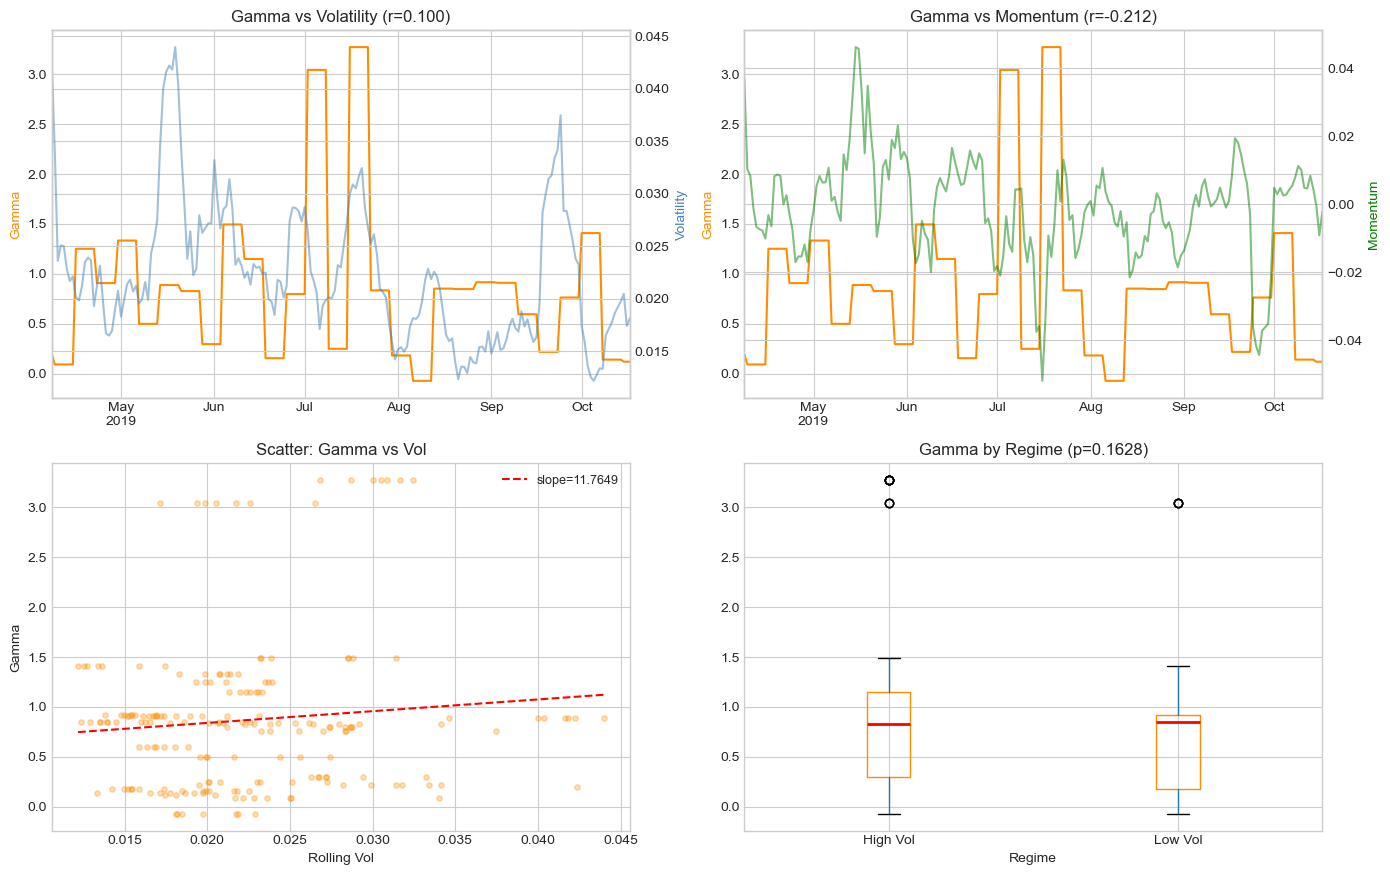

In [26]:
gamma_oos  = sac_gamma_test[_label_xai]
market_oos = ret_test.loc[gamma_oos.index]

rolling_vol = market_oos.std(axis=1).rolling(7).mean()
rolling_ret = market_oos.mean(axis=1).rolling(7).mean()

common_idx = gamma_oos.index.intersection(rolling_vol.dropna().index)
g  = gamma_oos.loc[common_idx]
rv = rolling_vol.loc[common_idx]
rm = rolling_ret.loc[common_idx]

corr_vol = g.corr(rv)
corr_mom = g.corr(rm)

vol_median = rv.median()
high_vol_mask  = rv >= vol_median
gamma_high_vol = g[high_vol_mask]
gamma_low_vol  = g[~high_vol_mask]

from scipy.stats import ttest_ind, spearmanr
t_stat, t_p = ttest_ind(gamma_high_vol, gamma_low_vol)
sp_rho_vol, sp_p_vol = spearmanr(g, rv)
sp_rho_mom, sp_p_mom = spearmanr(g, rm)

print(f'Pearson  Gamma~Vol : {corr_vol:.4f}')
print(f'Pearson  Gamma~Mom : {corr_mom:.4f}')
print(f'Spearman Gamma~Vol : {sp_rho_vol:.4f} (p={sp_p_vol:.4f})')
print(f'Spearman Gamma~Mom : {sp_rho_mom:.4f} (p={sp_p_mom:.4f})')
print(f'Gamma High Vol: {gamma_high_vol.mean():.4f} ± {gamma_high_vol.std():.4f}')
print(f'Gamma Low  Vol: {gamma_low_vol.mean():.4f} ± {gamma_low_vol.std():.4f}')
print(f'T-test p: {t_p:.4f} {"* Signifikan" if t_p < 0.05 else ""}')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ax1 = axes[0,0]; ax1b = ax1.twinx()
g.plot(ax=ax1, color='darkorange', linewidth=1.5, label='Gamma SAC')
rv.plot(ax=ax1b, color='steelblue', alpha=0.5, label='Rolling Vol')
ax1.set_ylabel('Gamma', color='darkorange')
ax1b.set_ylabel('Volatility', color='steelblue')
ax1.set_title(f'Gamma vs Volatility (r={corr_vol:.3f})')

ax2 = axes[0,1]; ax2b = ax2.twinx()
g.plot(ax=ax2, color='darkorange', linewidth=1.5, label='Gamma SAC')
rm.plot(ax=ax2b, color='green', alpha=0.5, label='Momentum')
ax2.set_ylabel('Gamma', color='darkorange')
ax2b.set_ylabel('Momentum', color='green')
ax2.set_title(f'Gamma vs Momentum (r={corr_mom:.3f})')

z = np.polyfit(rv, g, 1)
x_line = np.linspace(rv.min(), rv.max(), 100)
axes[1,0].scatter(rv, g, alpha=0.3, s=15, c='darkorange')
axes[1,0].plot(x_line, np.poly1d(z)(x_line), 'r--', linewidth=1.5, label=f'slope={z[0]:.4f}')
axes[1,0].set_xlabel('Rolling Vol'); axes[1,0].set_ylabel('Gamma')
axes[1,0].set_title('Scatter: Gamma vs Vol'); axes[1,0].legend(fontsize=9)

pd.DataFrame({'Gamma': g.values, 'Regime': ['High Vol' if m else 'Low Vol' for m in high_vol_mask]})\
  .boxplot(column='Gamma', by='Regime', ax=axes[1,1],
           boxprops=dict(color='darkorange'), medianprops=dict(color='red', linewidth=2))
axes[1,1].set_title(f'Gamma by Regime (p={t_p:.4f})')
plt.suptitle('')
plt.tight_layout()
plt.savefig('backtest_results/xai_regime_v2.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.4 Local SHAP Waterfall

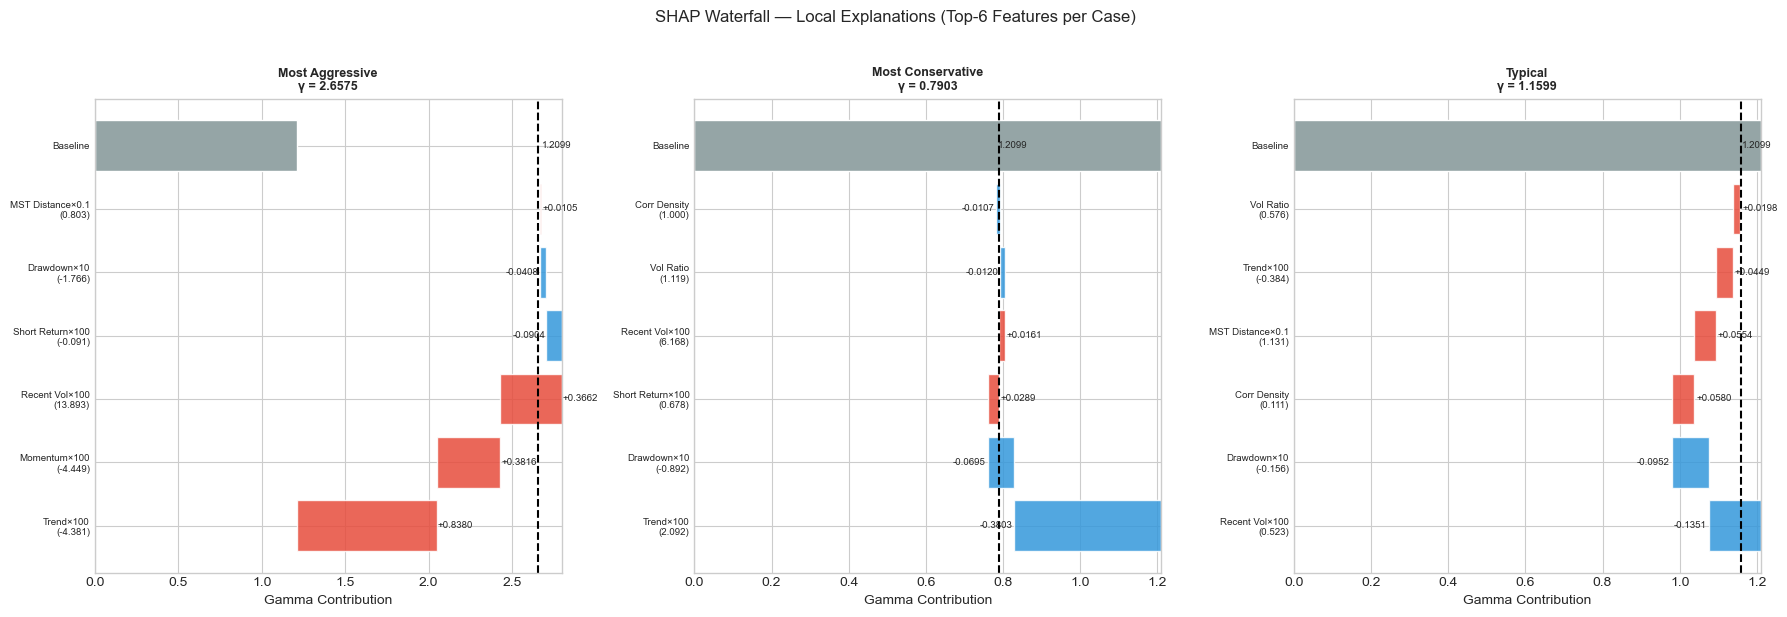

In [27]:
gamma_preds = get_gamma_predictions(sac_model_xai, X_obs[:100])
shap_vals   = np.array(shap_values)
baseline_g  = explainer.expected_value

idx_max    = np.argmax(gamma_preds[:100])
idx_min    = np.argmin(gamma_preds[:100])
idx_median = np.argmin(np.abs(gamma_preds[:100] - np.median(gamma_preds[:100])))
cases = {'Most Aggressive': idx_max, 'Most Conservative': idx_min, 'Typical': idx_median}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (case_name, idx) in zip(axes, cases.items()):
    sv = shap_vals[idx]; g_pred = gamma_preds[idx]
    top_idx = np.argsort(np.abs(sv))[::-1][:6]
    running = baseline_g
    y_items = [('Baseline', baseline_g, '#95a5a6')]
    for fi in top_idx[::-1]:
        y_items.insert(0, (f'{FEATURE_NAMES[fi]}\n({X_obs[idx][fi]:.3f})', sv[fi],
                           '#e74c3c' if sv[fi]>0 else '#3498db'))
    running = baseline_g
    for j, (name, val, color) in enumerate(y_items):
        if name == 'Baseline':
            ax.barh(j, val, color=color, edgecolor='white')
        else:
            ax.barh(j, val, left=running, color=color, edgecolor='white', alpha=0.85)
            running += val
        ax.text(running+(0.005 if val>=0 else -0.005), j,
                f'{val:+.4f}' if name!='Baseline' else f'{val:.4f}',
                va='center', ha='left' if val>=0 else 'right', fontsize=7)
    ax.set_yticks(range(len(y_items)))
    ax.set_yticklabels([n for n,_,_ in y_items], fontsize=7)
    ax.axvline(g_pred, color='black', linestyle='--', linewidth=1.5)
    ax.set_title(f'{case_name}\nγ = {g_pred:.4f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Gamma Contribution')

plt.suptitle('SHAP Waterfall — Local Explanations (Top-6 Features per Case)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('backtest_results/xai_waterfall_v2.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 12: 🆕 Summary Dashboard — Asymmetric Performance

Dashboard gabungan: performa + capture ratio + XAI regime.

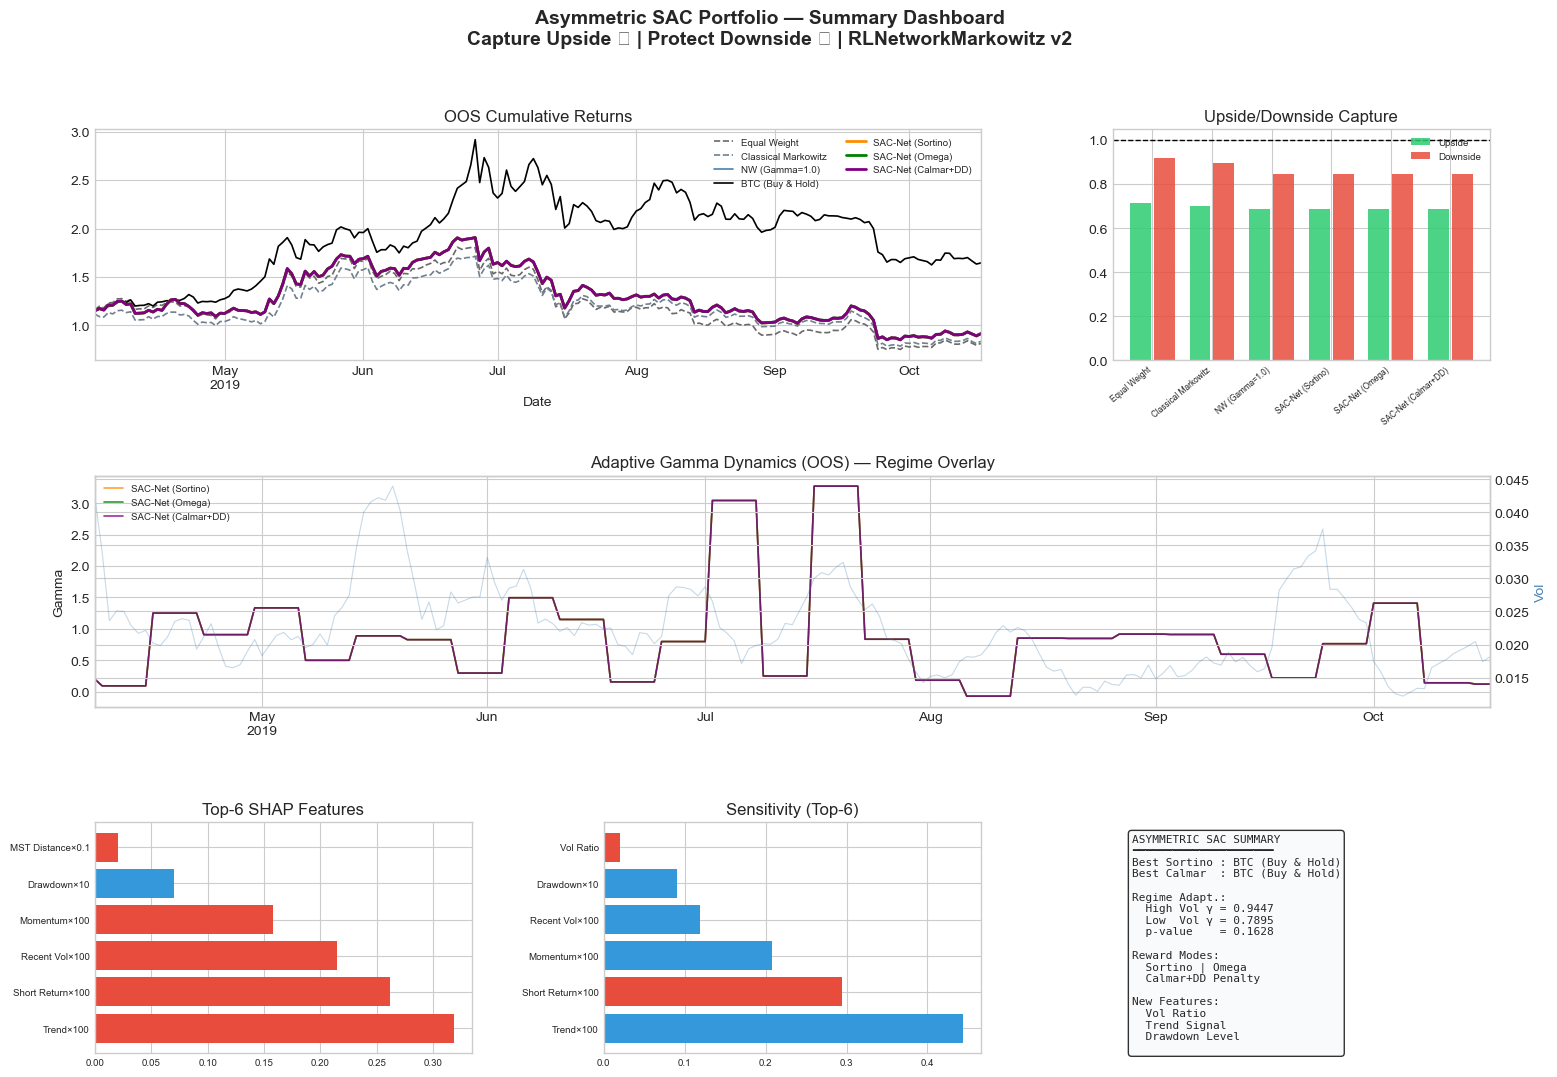


✅ Dashboard saved: backtest_results/dashboard_asymmetric.png
✅ Semua output tersimpan di folder: backtest_results/


In [28]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    'Asymmetric SAC Portfolio — Summary Dashboard\n'
    'Capture Upside ✅ | Protect Downside ✅ | RLNetworkMarkowitz v2',
    fontsize=14, fontweight='bold'
)

gs = fig.add_gridspec(3, 3, hspace=0.5, wspace=0.35)
ax_cum   = fig.add_subplot(gs[0, :2])
ax_cap   = fig.add_subplot(gs[0, 2])
ax_gamma = fig.add_subplot(gs[1, :])
ax_shap  = fig.add_subplot(gs[2, 0])
ax_sens  = fig.add_subplot(gs[2, 1])
ax_text  = fig.add_subplot(gs[2, 2])

# 1. Cumulative returns OOS
for name, r in results_test.items():
    (1+r).cumprod().plot(ax=ax_cum, label=name, color=COLORS.get(name,'gray'),
                          linewidth=2 if 'SAC' in name else 1.2,
                          linestyle='--' if 'Equal' in name or 'Classical' in name else '-')
ax_cum.set_title('OOS Cumulative Returns'); ax_cum.legend(fontsize=7, ncol=2)

# 2. Capture ratio
if 'capture_df_test' in dir():
    cd = capture_df_test.dropna()
    x2 = np.arange(len(cd))
    ax_cap.bar(x2-0.2, cd['Upside Capture'],   0.35, label='Upside',   color='#2ecc71', alpha=0.85)
    ax_cap.bar(x2+0.2, cd['Downside Capture'],  0.35, label='Downside', color='#e74c3c', alpha=0.85)
    ax_cap.axhline(1.0, color='black', linestyle='--', linewidth=1)
    ax_cap.set_xticks(x2); ax_cap.set_xticklabels(cd.index, rotation=40, ha='right', fontsize=6)
    ax_cap.set_title('Upside/Downside Capture'); ax_cap.legend(fontsize=7)

# 3. Gamma + vol overlay
ax_g2 = ax_gamma.twinx()
for label, g_s in sac_gamma_test.items():
    g_s.plot(ax=ax_gamma, label=label, color=COLORS.get(label,'gray'), alpha=0.8, linewidth=1.2)
rv.plot(ax=ax_g2, color='steelblue', alpha=0.3, linewidth=0.8, label='Vol')
ax_gamma.set_ylabel('Gamma'); ax_g2.set_ylabel('Vol', color='steelblue')
ax_gamma.set_title(f'Adaptive Gamma Dynamics (OOS) — Regime Overlay')
ax_gamma.legend(fontsize=7, loc='upper left')

# 4. SHAP bar (top 6)
top6_idx = sorted_idx[:6]
ax_shap.barh([FEATURE_NAMES[i] for i in top6_idx], mean_abs_shap[top6_idx],
             color=['#e74c3c' if shap_values.mean(0)[i]>0 else '#3498db' for i in top6_idx])
ax_shap.set_title('Top-6 SHAP Features'); ax_shap.tick_params(labelsize=7)

# 5. Sensitivity top 6
sd6 = sens_df.head(6)
ax_sens.barh(sd6['Feature'], sd6['|Δγ| avg'],
             color=['#e74c3c' if d>0 else '#3498db' for d in sd6['Δγ (+1 std)']])
ax_sens.set_title('Sensitivity (Top-6)'); ax_sens.tick_params(labelsize=7)

# 6. Text summary
ax_text.axis('off')
best_sar = stats_test['Sortino Ratio'].idxmax() if 'Sortino Ratio' in stats_test else '—'
best_cal = stats_test['Calmar Ratio'].idxmax()  if 'Calmar Ratio'  in stats_test else '—'
summary  = (
    'ASYMMETRIC SAC SUMMARY\n'
    '━━━━━━━━━━━━━━━━━━━━━\n'
    f'Best Sortino : {best_sar[:20]}\n'
    f'Best Calmar  : {best_cal[:20]}\n\n'
    f'Regime Adapt.:\n'
    f'  High Vol γ = {gamma_high_vol.mean():.4f}\n'
    f'  Low  Vol γ = {gamma_low_vol.mean():.4f}\n'
    f'  p-value    = {t_p:.4f}\n\n'
    f'Reward Modes:\n'
    f'  Sortino | Omega\n'
    f'  Calmar+DD Penalty\n\n'
    f'New Features:\n'
    f'  Vol Ratio\n'
    f'  Trend Signal\n'
    f'  Drawdown Level\n'
)
ax_text.text(0.05, 0.95, summary, transform=ax_text.transAxes,
             fontsize=8, va='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.8))

plt.savefig('backtest_results/dashboard_asymmetric.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Dashboard saved: backtest_results/dashboard_asymmetric.png')
print('✅ Semua output tersimpan di folder: backtest_results/')

## 📋 Ringkasan Improvements vs v1

| Komponen | v1 (Original) | v2 (Asymmetric) |
|----------|--------------|-----------------|
| **Reward** | Sharpe / excess_nw (simetris) | Sortino + Omega + Calmar (asimetris) |
| **Obs Space** | 9 features | **12 features** (+vol_ratio, trend, drawdown) |
| **Gamma Center** | Tetap = 1.0 | **Adaptif** berdasarkan regime |
| **DD Penalty** | Hanya `defensive` mode | **Eksplisit** di semua Calmar mode |
| **Metrics** | Sharpe, Calmar | +Sortino, Omega, **Upside/Downside Capture** |
| **XAI** | 9 features | **12 features** (3 regime fitur dapat diinterpretasi) |

## ⚠️ Limitasi Penelitian (wajib dicantumkan di tesis)
1. **No Transaction Cost** — hasil aktual ~0.05–0.20% lebih rendah per rebalancing
2. **Tanh Squashing** — gamma efektif tidak pernah menyentuh batas ±5 secara penuh
3. **3 Seeds** — estimasi statistik terbatas; tambah seed jika resources memungkinkan
4. **Adaptive gamma center** adalah rule-based (heuristic), bukan learned — bisa dikembangkan dengan meta-RL
5. **SHAP KernelExplainer** adalah approximasi (model-agnostic), bukan exact Shapley